# Crime Rate Prediction for Indian Metropolitan Cities

## Objective

To predict future crime rates in Indian metropolitan cities using historical NCRB crime data and machine learning algorithms.

## Algorithms Compared

- Linear Regression
- K-Nearest Neighbors (KNN)
- XGBoost
- Random Forest
- AdaBoost

## Final Selected Model

Random Forest Regressor


## 1) Data Preprocessing (Load + Clean + Create Features)


In [1]:
import pandas as pd  # Imports pandas for working with tabular CSV-like data.
import numpy as np  # Imports numpy for numerical operations (arrays, math utilities).

import matplotlib.pyplot as plt  # Imports matplotlib plotting interface.
import seaborn as sns  # Imports seaborn for nicer statistical visualizations.

from sklearn.preprocessing import LabelEncoder  # Imports LabelEncoder to convert city names to numeric codes.
from sklearn.model_selection import train_test_split  # Imports train_test_split to create train/test datasets.

from sklearn.metrics import (
    r2_score,  # Imports R^2 metric to measure goodness of fit.
    mean_absolute_error,  # Imports MAE metric (not used later in this notebook).
    mean_squared_error  # Imports MSE metric (not used later in this notebook).
)

import joblib  # Imports joblib to load/save trained model objects.

df = pd.read_csv("crp.csv")  # Loads the crime dataset from the CSV file into a DataFrame.

print("Dataset Shape:", df.shape)  # Prints dataset rows/columns count for quick sanity check.

df.head()  # Displays the first few rows to inspect structure (no variable change).

df.info()  # Shows column types, non-null counts, and memory usage.
df.describe()  # Produces summary statistics for numeric columns.
df.isnull().sum()  # Counts missing values per column.

df = df.dropna(axis=1, how='all')  # Drops columns where all values are missing (all-NaN).

df = df.dropna(how='all')  # Drops rows where all values are missing (all-NaN).

df["Prev_Year_Crime_Rate"] = (
    df["Prev_Year_Crime_Rate"]  # Selects the column containing previous-year crime rate values.
    .fillna(0)  # Replaces missing previous crime-rate values with 0 so math/modeling can proceed.
)

print(df.shape)  # Prints the updated DataFrame shape after cleaning.

df["Crime_Rate"] = (
    df["Total_Crime"] /  # Takes total crime counts.
    df["Population (in Lakhs) (2011)+"]  # Divides by population (in lakhs) to normalize crime per population.
)

df["Prev_Year_Crime_Rate"] = (
    df["Prev_Year_Crime_Rate"]  # Re-selects previous-year crime-rate column.
    .fillna(0)  # Replaces any remaining missing values with 0.
)

print(df.shape)  # Prints dataset dimensions after feature creation.

df = df.sort_values(["City", "Year"])  # Sorts by city and year so lag features align chronologically.

df["Prev_1"] = df.groupby("City")["Crime_Rate"].shift(1)  # Creates lag-1 crime rate per city.
df["Prev_2"] = df.groupby("City")["Crime_Rate"].shift(2)  # Creates lag-2 crime rate per city.
df["Prev_3"] = df.groupby("City")["Crime_Rate"].shift(3)  # Creates lag-3 crime rate per city.

df["Prev_1"] = df["Prev_1"].fillna(0)  # Fills missing lag values (first years) with 0.
df["Prev_2"] = df["Prev_2"].fillna(0)  # Fills missing lag values with 0.
df["Prev_3"] = df["Prev_3"].fillna(0)  # Fills missing lag values with 0.

df.head()  # Shows sample rows to verify lag columns were created correctly.

le = LabelEncoder()  # Creates a LabelEncoder instance to map city names to integer IDs.
df["City"] = le.fit_transform(df["City"])  # Fits encoder on city column and replaces City with integer codes.
df.head()  # Shows first rows to confirm City is now numeric.


Dataset Shape: (1053, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           209 non-null    float64
 1   City                           209 non-null    object 
 2   Population (in Lakhs) (2011)+  209 non-null    float64
 3   Murder                         209 non-null    float64
 4   Kidnapping                     209 non-null    float64
 5   Crime against women            209 non-null    float64
 6   Crime against children         209 non-null    float64
 7   Crime Committed by Juveniles   209 non-null    float64
 8   Crime against Senior Citizen   209 non-null    float64
 9   Crime against SC               209 non-null    float64
 10  Crime against ST               209 non-null    float64
 11  Economic Offences              209 non-null    float64
 12  Cyber Crimes          

,Year,City,Population (in Lakhs) (2011)+,Murder,Kidnapping,Crime against women,Crime against children,Crime Committed by Juveniles,Crime against Senior Citizen,Crime against SC,Crime against ST,Economic Offences,Cyber Crimes,Total_Crime,Crime_Rate,Prev_Year_Crime_Rate,Prev_1,Prev_2,Prev_3
0,2014.0,0,63.52,82.0,367.0,1371.0,437.0,215.0,68.0,66.0,6.0,399.0,32.0,3043.0,47.906171,0.000000,0.000000,0.000000,0.000000
1,2015.0,0,63.52,94.0,332.0,1067.0,609.0,157.0,17.0,60.0,9.0,378.0,28.0,2751.0,43.309194,0.000479,47.906171,0.000000,0.000000
2,2016.0,0,63.52,103.0,376.0,1126.0,481.0,258.0,362.0,96.0,10.0,479.0,77.0,3368.0,53.022670,0.000433,43.309194,47.906171,0.000000
3,2017.0,0,63.52,90.0,263.0,1405.0,600.0,405.0,534.0,119.0,6.0,608.0,112.0,4142.0,65.207809,0.000530,53.022670,43.309194,47.906171
4,2018.0,0,63.52,98.0,277.0,1416.0,733.0,352.0,733.0,145.0,9.0,842.0,212.0,4817.0,75.834383,0.000652,65.207809,53.022670,43.309194


## 2) Data Visualization


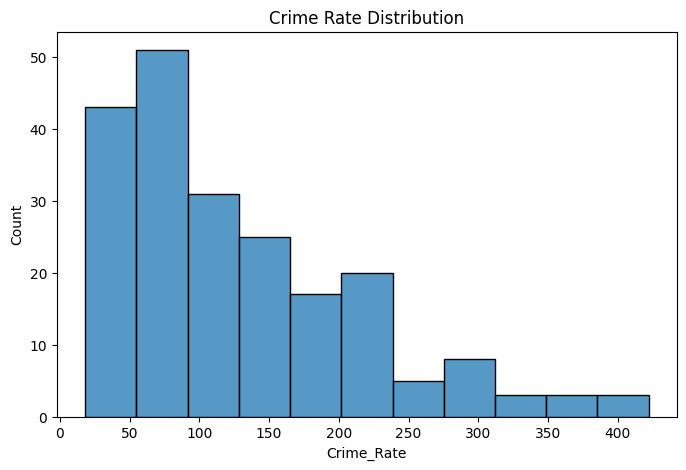

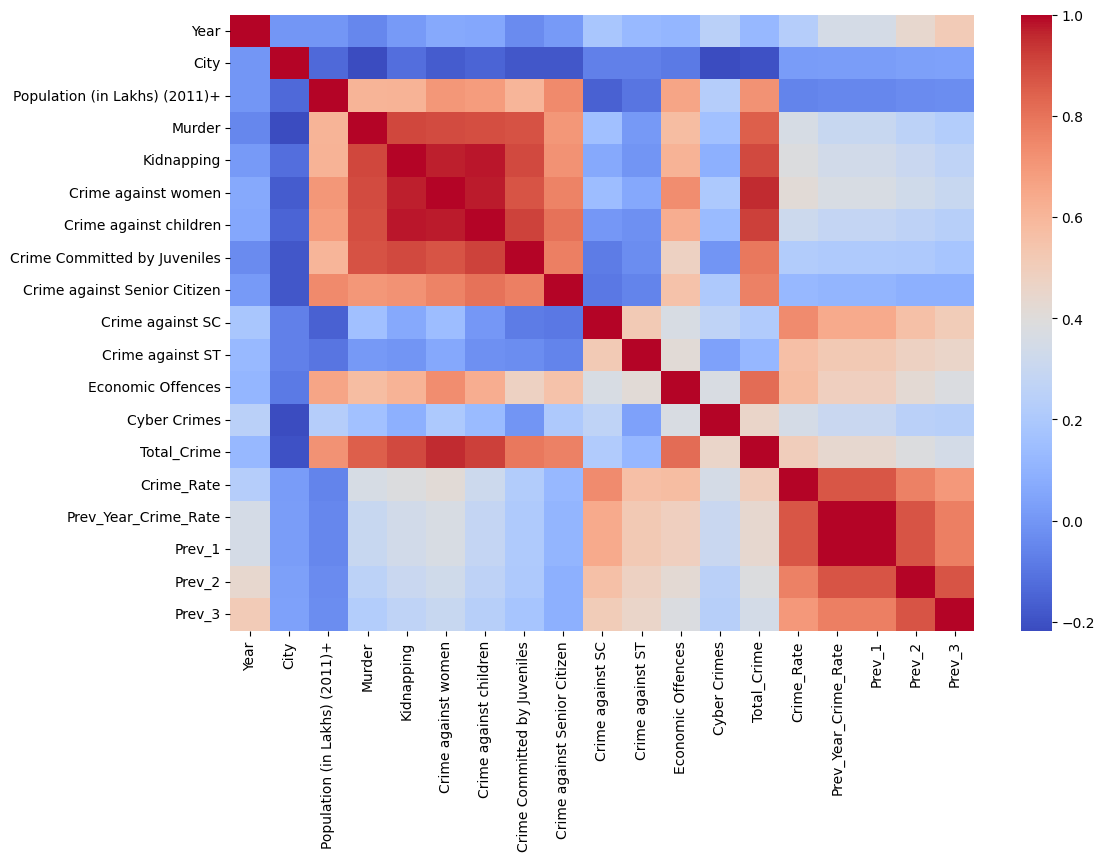

In [2]:
plt.figure(figsize=(8,5))  # Creates a new figure with a specified size for the histogram.
sns.histplot(df["Crime_Rate"])  # Plots distribution of the crime rate values.
plt.title("Crime Rate Distribution")  # Adds a title to the histogram.
plt.show()  # Renders the histogram plot.

plt.figure(figsize=(12,8))  # Creates a new figure with bigger size for correlation heatmap.
sns.heatmap(
    df.corr(numeric_only=True),  # Computes correlation matrix for numeric columns only.
    cmap="coolwarm"  # Sets color map theme for the heatmap.
)
plt.show()  # Renders the heatmap plot.


## 3) Feature Selection + Train/Test Split


In [3]:
X = df[[
    "Year",  # Feature: year (time trend).
    "City",  # Feature: encoded city ID.
    "Population (in Lakhs) (2011)+",  # Feature: population for normalization context.
    "Prev_1",  # Feature: crime rate from previous year (lag 1).
    "Prev_2",  # Feature: crime rate from two years ago (lag 2).
    "Prev_3"  # Feature: crime rate from three years ago (lag 3).
]]  # Selects the chosen feature columns.

y = df["Crime_Rate"]  # Target variable: the crime rate that models should learn.

X_train, X_test, y_train, y_test = train_test_split(  # Splits data into training and testing sets.
    X,  # Uses feature matrix X.
    y,  # Uses target vector y.
    test_size=0.20,  # Reserves 20% for testing.
    random_state=42  # Fixes randomness for reproducibility.
)


## 4) Model Evaluation (Compare Multiple Algorithms using R²)


In [4]:
from sklearn.linear_model import LinearRegression  # Imports Linear Regression model.
lr = LinearRegression()  # Creates a linear regression estimator.
lr.fit(X_train, y_train)  # Trains linear regression on training data.
lr_pred = lr.predict(X_test)  # Predicts crime rates on the test set.
lr_r2 = r2_score(y_test, lr_pred)  # Computes R^2 for linear regression.
print("R² =", lr_r2)  # Prints the R^2 score.

from sklearn.neighbors import KNeighborsRegressor  # Imports KNN regressor.
knn = KNeighborsRegressor(n_neighbors=5)  # Creates KNN with k=5 neighbors.
knn.fit(X_train, y_train)  # Trains KNN regressor.
knn_pred = knn.predict(X_test)  # Predicts on test set.
knn_r2 = r2_score(y_test, knn_pred)  # Computes R^2 for KNN.
print("R² =", knn_r2)  # Prints R^2 score.

from xgboost import XGBRegressor  # Imports XGBoost regressor.
xgb = XGBRegressor(  # Creates an XGBoost model with chosen hyperparameters.
    n_estimators=300,  # Number of trees to build.
    learning_rate=0.05,  # Learning rate.
    max_depth=5,  # Tree depth.
    random_state=42  # Makes training reproducible.
)
xgb.fit(X_train, y_train)  # Trains XGBoost.
xgb_pred = xgb.predict(X_test)  # Predicts on test set.
xgb_r2 = r2_score(y_test, xgb_pred)  # Computes R^2 for XGBoost.
print("R² =", xgb_r2)  # Prints XGBoost R^2.

from sklearn.ensemble import RandomForestRegressor  # Imports Random Forest regressor.
rf = RandomForestRegressor(  # Creates Random Forest with selected parameters.
    n_estimators=200,  # Number of trees in the forest.
    random_state=42  # Fix randomness for reproducibility.
)
rf.fit(X_train, y_train)  # Trains the Random Forest model.
rf_pred = rf.predict(X_test)  # Predicts crime rates on test set.
rf_r2 = r2_score(y_test, rf_pred)  # Computes R^2 for Random Forest.
print("R² =", rf_r2)  # Prints Random Forest R^2.

from sklearn.ensemble import AdaBoostRegressor  # Imports AdaBoost regressor.
ada = AdaBoostRegressor(n_estimators=200, random_state=42)  # Creates AdaBoost model.
ada.fit(X_train, y_train)  # Trains AdaBoost model.
ada_pred = ada.predict(X_test)  # Predicts on test set.
ada_r2 = r2_score(y_test, ada_pred)  # Computes R^2 for AdaBoost.
print("R² =", ada_r2)  # Prints AdaBoost R^2.

from sklearn.ensemble import ExtraTreesRegressor  # Imports Extra Trees regressor.
et = ExtraTreesRegressor(n_estimators=200, random_state=42)  # Creates Extra Trees model.
et.fit(X_train, y_train)  # Trains Extra Trees on training data.
et_pred = et.predict(X_test)  # Predicts on test data.
et_r2 = r2_score(y_test, et_pred)  # Computes R^2 score.
print("R² =", et_r2)  # Prints Extra Trees R^2.

from sklearn.tree import DecisionTreeRegressor  # Imports Decision Tree regressor.
dt = DecisionTreeRegressor(max_depth=5, random_state=42)  # Creates Decision Tree model.
dt.fit(X_train, y_train)  # Trains decision tree.
dt_pred = dt.predict(X_test)  # Predicts on test data.
dt_r2 = r2_score(y_test, dt_pred)  # Computes R^2.
print("R² =", dt_r2)  # Prints Decision Tree R^2.

comparison = pd.DataFrame({  # Creates a DataFrame to compare model scores.
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],
    "R2 Score": [lr_r2, dt_r2, knn_r2, rf_r2, et_r2, xgb_r2]  # R^2 scores per model.
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)  # Sorts so best model appears first.
comparison  # Displays the sorted comparison table.


R² = 0.8046478156420529
R² = 0.7334552124877478
R² = 0.8028569811580822
R² = 0.8124440476371658
R² = 0.8027837286016097
R² = 0.8065250550499585
R² = 0.7595911915847897


,Model,R2 Score
3,Random Forest,0.812444
4,Extra Trees,0.806525
0,Linear Regression,0.804648
5,XGBoost,0.802857
1,Decision Tree,0.759591
2,KNN,0.733455


## 5) Final Model Selection + Training
Based on the experimental results, Random Forest Regressor was selected as the final model due to its strong predictive performance and robustness.


In [5]:
from sklearn.ensemble import RandomForestRegressor  # Imports Random Forest regressor for final training.
final_model = RandomForestRegressor(n_estimators=200, random_state=42)  # Creates final Random Forest model.
final_model.fit(X, y)  # Trains the final model on the complete dataset.
print("Final Model Trained Successfully")  # Confirms training finished successfully.

joblib.dump(final_model, "crime_rate_model.pkl")  # Saves trained model for later predictions in the app.
joblib.dump(le, "city_encoder.pkl")  # Saves LabelEncoder so the app can encode city names consistently.
print("Model and Encoder Saved")  # Confirms both objects were saved to disk.


Final Model Trained Successfully
Model and Encoder Saved


## 6) Prediction Function (Single-Step Forecast for One Year)


In [6]:
def predict_crime_rate(year, city, population, prev1, prev2, prev3):  # Predicts crime rate for given inputs.
    city_code = le.transform([city])[0]  # Converts city name into encoded numeric city ID.
    input_data = pd.DataFrame({  # Builds the exact feature schema expected by the trained model.
        "Year": [year],  # Future year value fed to the model.
        "City": [city_code],  # Encoded city ID.
        "Population (in Lakhs) (2011)+": [population],  # Population feature (used as model input).
        "Prev_1": [prev1],  # Lag-1 crime rate feature.
        "Prev_2": [prev2],  # Lag-2 crime rate feature.
        "Prev_3": [prev3],  # Lag-3 crime rate feature.
    })
    prediction = final_model.predict(input_data)  # Runs Random Forest to predict crime rate.
    return prediction[0]  # Returns scalar predicted crime rate for that year.


## 7) Recursive Forecasting (Predict Multiple Future Years)


In [7]:
def forecast_future_years(city, population, prev1, prev2, prev3, start_year, target_year):  # Builds a multi-year forecast.
    results = []  # Stores [year, predicted_crime_rate] rows.
    for year in range(start_year + 1, target_year + 1):  # Forecast each next year.
        predicted = predict_crime_rate(year, city, population, prev1, prev2, prev3)  # Predict next year based on current lag window.
        results.append([year, predicted])  # Save result row.
        prev3 = prev2  # Shift lag window: prev2 becomes prev3.
        prev2 = prev1  # Shift lag window: prev1 becomes prev2.
        prev1 = predicted  # Shift lag window: predicted becomes prev1 for next step.
    return pd.DataFrame(results, columns=["Year", "Predicted_Crime_Rate"])  # Return forecast table.


## 8) Forecast Example + Plot


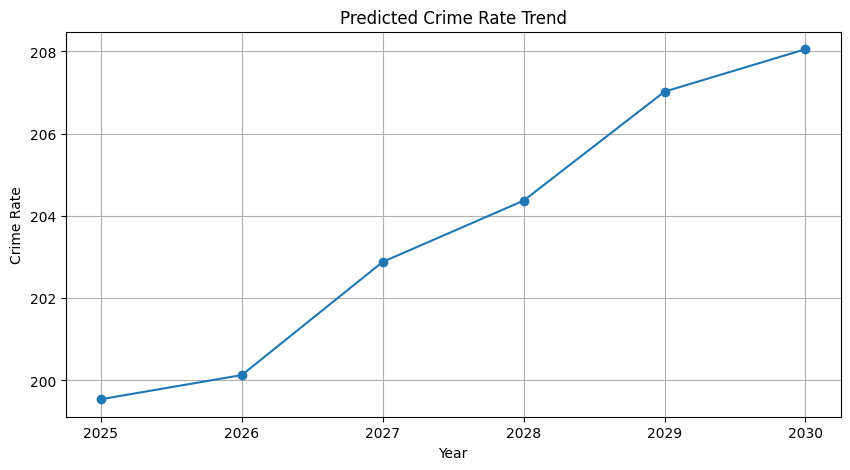

In [8]:
city_data = df[df["City"] == le.transform(["Hyderabad"])[0]]  # Filter dataset for Hyderabad (encoded).
city_data[["Year", "Crime_Rate"]].tail()  # Show last known historical values for Hyderabad.
forecast = forecast_future_years(  # Run recursive forecasting for Hyderabad.
    city="Hyderabad", population=77.49, prev1=185, prev2=175, prev3=160,
    start_year=2024, target_year=2030
)
forecast  # Display forecast output table.

plt.figure(figsize=(10,5))  # Create figure for line chart.
plt.plot(forecast["Year"], forecast["Predicted_Crime_Rate"], marker="o")  # Plot predicted crime rate per year.
plt.title("Predicted Crime Rate Trend")  # Chart title.
plt.xlabel("Year")  # X-axis label.
plt.ylabel("Crime Rate")  # Y-axis label.
plt.grid(True)  # Enable grid.
plt.show()  # Render plot.
